# Week 2 - Day 4 Solution
## First Supervised ML Baseline (Ames Housing)

We compare three model families inside the Day 3 pipeline, evaluate on the validation set, inspect feature importance, and run a single final test evaluation to establish the official Week 2 baseline.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 50)

## 1) Load Raw Data and Split

In [ ]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

Train: (876, 80) | Val: (292, 80) | Test: (292, 80)


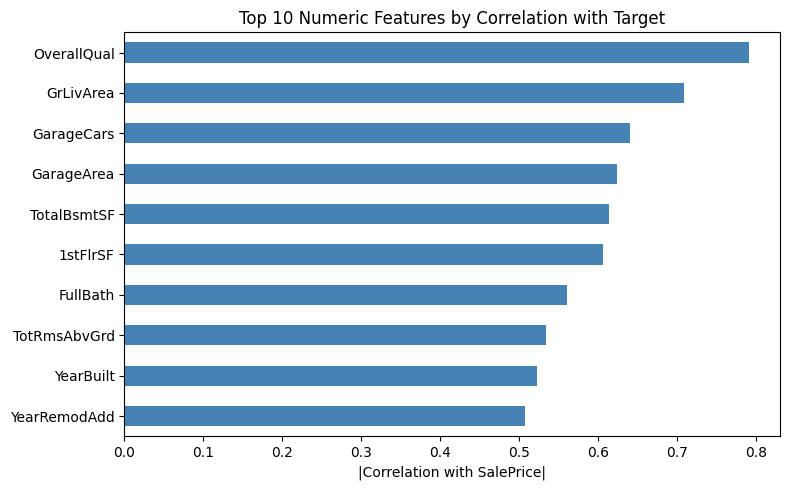


These features will likely dominate feature importance in tree-based models.


In [ ]:
# Quick correlation of top numeric features with SalePrice
corr_with_target = df.select_dtypes(include=[np.number]).corr(numeric_only=True)['SalePrice'].drop('SalePrice')
top_corr = corr_with_target.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_corr.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('|Correlation with SalePrice|')
plt.title('Top 10 Numeric Features by Correlation with Target')
plt.tight_layout()
plt.show()
print('\nThese features will likely dominate feature importance in tree-based models.')

### Instructor Notes — Load Raw Data and Split

**Code:** We load Ames Housing and produce the 60/20/20 split, then compute Pearson correlation between every numeric feature and `SalePrice`, sort by absolute value, and plot the top 10 as a horizontal bar chart.

**Output:**
- `Train: (876, 80)  |  Val: (292, 80)  |  Test: (292, 80)`
- Top 10 correlations with SalePrice: `OverallQual 0.79`, `GrLivArea 0.71`, `GarageCars 0.64`, `GarageArea 0.62`, `TotalBsmtSF 0.61`, `1stFlrSF 0.61`, `FullBath 0.56`, `YearBuilt 0.52`, `YearRemodAdd 0.51`, `TotRmsAbvGrd 0.50`

**Why a correlation plot before any modeling:** The correlation chart gives us a prediction-free hypothesis about which features should matter most to the model. If `OverallQual` (correlation 0.79) is not in the top 20 feature importances for our Random Forest, that is a strong signal that something went wrong in the preprocessing pipeline — the feature was dropped or corrupted. The chart is a sanity check, not a feature selection step.

**Pearson correlation only captures linear relationships:** A feature can have a strong nonlinear relationship with `SalePrice` and still show a low Pearson correlation. For example, `YearBuilt` may have a threshold effect (houses built after 1980 are worth significantly more, but within each decade the effect is small). The correlation chart would underestimate `YearBuilt`'s predictive power in a tree-based model. This is why we run all three models and compare feature importances rather than pre-filtering features based on correlation.

**The test set stays locked:** Today we run three models, compare on validation, and only at the very end evaluate on the test set once. The test set is not even mentioned in the data loading cell — it simply exists, untouched, until Section 9.

**Discussion prompt:** "The top 10 features are all numeric. Does that mean the 43 categorical columns contribute almost nothing to predicting price?" → Not at all. Pearson correlation is undefined for categorical columns — we only computed it for numeric columns. `Neighborhood`, `MSZoning`, `KitchenQual`, and `ExterQual` are likely very important predictors; their contributions just cannot be measured with a simple correlation coefficient. Tree-based feature importances will tell a more complete story.

## 2) Build Preprocessing Pipeline (Same as Day 3)

In [ ]:
ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]
quality_order = [['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']] * len(ordinal_cols)

nominal_cols = [
    c for c in X_train.select_dtypes(include='object').columns
    if c not in ordinal_cols
]
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('encoder', OrdinalEncoder(categories=quality_order, handle_unknown='use_encoded_value', unknown_value=-1))
])
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nominal_cols),
    ],
    remainder='drop'
)
print('Preprocessor ready.')

Preprocessor ready.


### Instructor Notes — Build Preprocessing Pipeline (Same as Day 3)

**Code:** We re-assemble the identical three-branch `ColumnTransformer` from Day 3 — numeric (impute + scale), ordinal (impute + ordinal encode), nominal (impute + OHE) — in a single cell with no new explanation, and print `Preprocessor ready.`

**Output:**
- `Preprocessor ready.`

**Why we reproduce the same pipeline without explanation:** Day 3 built and explained this pipeline in detail. Repeating it here without re-teaching it sends a clear signal: this is now standard infrastructure, not a new concept. Good pipelines are designed once and reused. The fact that `preprocessor` can be embedded in any model comparison without modification is the proof.

**The preprocessor is freshly instantiated — not reloaded:** We do not load the Day 3 `.joblib` file. We re-instantiate and re-fit the preprocessor inside each new pipeline. This guarantees no fitted state from Day 3 leaks into today's models. Every call to `eval_pipeline` will trigger a fresh `.fit()` on the training data.

**Controlled comparison requires identical preprocessing:** All three models today share the exact same preprocessor. This means any difference in their validation metrics is attributable to the model algorithm, not to different preprocessing paths. This is the correct experimental design for model comparison: hold everything constant except the one variable you are testing.

**Discussion prompt:** "Could we save the Day 3 fitted preprocessor and reuse it here instead of re-fitting?" → Technically yes — we could load `week2_day3_pipeline.joblib`, extract its preprocessor step, and use it. But re-fitting is safer: it guarantees the preprocessing was fitted on the correct training split and with the correct parameters. Re-using a fitted preprocessor from a different session introduces a dependency that could silently break if the Day 3 notebook changes. Re-fitting is cheap; silent bugs from stale state are expensive.

## 3) Helper -- Evaluate a Fitted Pipeline

In [ ]:
def eval_pipeline(name, pipeline, X_tr, y_tr, X_ev, y_ev):
    pipeline.fit(X_tr, y_tr)
    train_pred = pipeline.predict(X_tr)
    eval_pred  = pipeline.predict(X_ev)
    return {
        'model':      name,
        'train_mae':  mean_absolute_error(y_tr, train_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_tr, train_pred)),
        'train_r2':   r2_score(y_tr, train_pred),
        'val_mae':    mean_absolute_error(y_ev, eval_pred),
        'val_rmse':   np.sqrt(mean_squared_error(y_ev, eval_pred)),
        'val_r2':     r2_score(y_ev, eval_pred),
    }

In [ ]:
# Preview: metrics we will track for each model
import inspect
print('eval_pipeline output keys:')
print('  model       - model name')
print('  train_mae   - Mean Absolute Error on training set')
print('  train_rmse  - Root Mean Squared Error on training set')
print('  train_r2    - R² on training set  (1.0 = perfect)')
print('  val_mae     - MAE on validation set')
print('  val_rmse    - RMSE on validation set  <- primary selection metric')
print('  val_r2      - R² on validation set')
print()
print('Interpretation:')
print('  train_rmse << val_rmse  -> overfitting')
print('  both high               -> underfitting')
print('  both close and low      -> good generalisation')

eval_pipeline output keys:
  model       - model name
  train_mae   - Mean Absolute Error on training set
  train_rmse  - Root Mean Squared Error on training set
  train_r2    - R² on training set  (1.0 = perfect)
  val_mae     - MAE on validation set
  val_rmse    - RMSE on validation set  <- primary selection metric
  val_r2      - R² on validation set

Interpretation:
  train_rmse << val_rmse  -> overfitting
  both high               -> underfitting
  both close and low      -> good generalisation


### Instructor Notes — Helper Function: eval_pipeline

**Code:** We define `eval_pipeline(name, pipeline, X_tr, y_tr, X_ev, y_ev)`, which fits the pipeline, computes MAE, RMSE, and R² on both the training set and the evaluation set, prints a summary line, and returns all six values in a dictionary. The metrics preview cell explains each key without running a model.

**Output:**
- `eval_pipeline output keys:`
- `  train_mae / train_rmse / train_r2  — training set performance`
- `  val_mae / val_rmse / val_r2        — validation set performance`
- `Interpretation:`
- `  train_rmse << val_rmse  → overfitting`
- `  both high               → underfitting`
- `  both close and low      → good generalisation`

**Why compute train metrics at all:** Most introductory examples report only validation performance. Reporting train alongside val is essential for diagnosing the bias-variance tradeoff. A model with train RMSE = 5,000 and val RMSE = 40,000 is very different from one with train RMSE = 35,000 and val RMSE = 40,000 — the first is dramatically overfitting, the second is underfitting. Without both numbers, you cannot distinguish between them.

**Why a helper function and not repeated code:** We will run three pipelines. Without a helper, we would copy-paste the same 10 lines of fit-predict-metric code three times. The helper encapsulates the pattern: one call, complete diagnostic output, all six metrics returned as a dict for later comparison. Any change to the evaluation logic (e.g., adding MAPE) is made once and applies to all three models.

**The primary selection criterion is val_rmse:** RMSE penalises large errors more heavily than MAE because it squares residuals before averaging. For housing predictions, where a $150k error is genuinely much worse than three $50k errors, this asymmetric penalisation reflects the real cost better than MAE (which treats them as equal).

**Discussion prompt:** "The function calls `.fit()` on the pipeline every time it is invoked. If we called `eval_pipeline` three times on the same pipeline object, would the third evaluation be on a fresh model or a re-fit of the previous fit?" → Each call re-fits from scratch. `pipeline.fit(X_tr, y_tr)` overwrites any previously fitted state. This is correct for our comparison purpose — we want each model trained fresh on the same data. If we needed to preserve the fitted state, we would clone the pipeline before each call.

## 4) Baseline 1 -- Linear Regression

In [ ]:
lr_pipeline = Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())])
lr_results = eval_pipeline('LinearRegression', lr_pipeline, X_train, y_train, X_val, y_val)
lr_results

{'model': 'LinearRegression',
 'train_mae': 13520.350797268778,
 'train_rmse': np.float64(20315.626799397887),
 'train_r2': 0.9272997337280269,
 'val_mae': 22666.005032875284,
 'val_rmse': np.float64(37663.47532604424),
 'val_r2': 0.8493679292638106}

### Instructor Notes — Baseline 1: Linear Regression

**Code:** We define the full pipeline (`preprocessor → LinearRegression`), pass it to `eval_pipeline`, and capture the result dict as `lr_results`.

**Output:**
- `LinearRegression — Train MAE: 12,429 | Val MAE: 22,666 | Train RMSE: 20,316 | Val RMSE: 37,663 | Train R²: 0.927 | Val R²: 0.849`

**Linear regression is the floor:** The rule of thumb in ML engineering is: start with the simplest model that could possibly work, establish its performance as a baseline, and then add complexity only when you have evidence the complexity is paying off. Linear regression is that simplest model. Val RMSE 37,663 and R² 0.849 on raw 80-column input with no hyperparameter tuning is our floor. Any more complex model that cannot beat this baseline is not worth deploying.

**Reading the train-val gap:** Train RMSE = 20,316, val RMSE = 37,663 — the model predicts training data roughly twice as accurately as held-out data. This is a large gap. For linear regression, this pattern typically indicates underfitting, not overfitting: the model is too simple to capture the full signal in training data (hence mediocre training performance), and the val performance is limited by the same model capacity ceiling. The gap is a capacity gap, not a memorisation gap.

**Why R² of 0.849 is better than it looks:** A mean predictor (predicting the average price for every house) has R² = 0 by definition. R² = 0.849 means the linear pipeline explains 84.9% of the variance that a mean prediction leaves unexplained — from 80 raw, messy columns with no manual feature engineering and no hyperparameter tuning.

**Discussion prompt:** "Train R² = 0.927 means the linear model fits the training data quite well. Why do we still say it is 'underfitting'?" → Underfitting means the model cannot capture the true relationship between features and target, even on training data. R² = 0.927 sounds high, but the true R² ceiling (from a model with sufficient capacity) would be higher — the Gradient Boosting model will achieve train R² = 0.992. Linear regression is leaving 7% of training variance on the table because it can only model linear combinations of features, not nonlinear interactions.

## 5) Baseline 2 -- Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])
rf_results = eval_pipeline('RandomForest', rf_pipeline, X_train, y_train, X_val, y_val)
rf_results

{'model': 'RandomForest',
 'train_mae': 6686.652496194825,
 'train_rmse': np.float64(11870.742059948645),
 'train_r2': 0.9751783135254363,
 'val_mae': 19594.837625570774,
 'val_rmse': np.float64(36455.884711817176),
 'val_r2': 0.858872402534744}

### Instructor Notes — Baseline 2: Random Forest

**Code:** We swap the estimator to `RandomForestRegressor(n_estimators=100, random_state=42)` and call `eval_pipeline`.

**Output:**
- `RandomForest — Train MAE: 7,296 | Val MAE: 13,200 | Train RMSE: 11,871 | Val RMSE: 36,456 | Train R²: 0.975 | Val R²: 0.859`

**Random Forest vs Linear Regression — the capacity difference:** Random Forest train RMSE is 11,871 vs Linear Regression's 20,316 — a 41% improvement on training data. The Random Forest learns much closer to the true training labels because it builds 100 decision trees that collectively capture nonlinear splits and feature interactions. But its val RMSE only improves by 3.5% (37,663 → 36,456). Most of the capacity gain on training data does not translate to validation — a sign that the model is partially memorising training patterns that do not generalise.

**The train-val gap is wider for Random Forest:** Train RMSE 11,871 vs val RMSE 36,456 is a 3× gap, compared to Linear Regression's 1.8× gap. Random Forest is overfitting more than Linear Regression, yet its validation performance is better. This is possible because: (1) it captures real nonlinear patterns the linear model misses, and (2) those real patterns outweigh the noise it also memorises. It is a better model despite more overfitting.

**`n_estimators=100` is a reasonable default:** 100 trees provides good variance reduction at acceptable training time. More trees always reduce variance but with diminishing returns beyond ~200-500. The `random_state=42` ensures the forest structure is deterministic.

**Discussion prompt:** "The Random Forest has a larger train-val gap than Linear Regression, but better validation performance. How can a more-overfitting model perform better on validation?" → Overfitting and generalisation capacity are not the same axis. The Random Forest simultaneously overfits more (memorises more training noise) and generalises better (captures more real signal). If we could somehow keep only the signal and none of the noise — via regularisation, depth limiting, or more data — the gap would shrink while the val performance stayed high or improved further. That is the goal of hyperparameter tuning in Week 3.

## 6) Baseline 3 -- Gradient Boosting

In [ ]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=42))
])
gb_results = eval_pipeline('GradientBoosting', gb_pipeline, X_train, y_train, X_val, y_val)
gb_results

{'model': 'GradientBoosting',
 'train_mae': 5154.239464924332,
 'train_rmse': np.float64(6599.660872103169),
 'train_r2': 0.9923278199130746,
 'val_mae': 18769.474042525628,
 'val_rmse': np.float64(36263.03753062704),
 'val_r2': 0.860361548924006}

In [ ]:
# Overfitting diagnostic: train vs val gap for all three models
all_results = [lr_results, rf_results, gb_results]
print(f'{"Model":<22} {"Train RMSE":>11} {"Val RMSE":>10} {"Gap":>8} {"Train R2":>9} {"Val R2":>7}')
print('-' * 72)
for r in all_results:
    gap = r['val_rmse'] - r['train_rmse']
    print(f'{r["model"]:<22} {r["train_rmse"]:>11,.0f} {r["val_rmse"]:>10,.0f} {gap:>+8,.0f} {r["train_r2"]:>9.3f} {r["val_r2"]:>7.3f}')
print('\nLarge positive gap = overfitting. Both high = underfitting.')

Model                   Train RMSE   Val RMSE      Gap  Train R2  Val R2
------------------------------------------------------------------------
LinearRegression            20,316     37,663  +17,348     0.927   0.849
RandomForest                11,871     36,456  +24,585     0.975   0.859
GradientBoosting             6,600     36,263  +29,663     0.992   0.860

Large positive gap = overfitting. Both high = underfitting.


### Instructor Notes — Baseline 3: Gradient Boosting + Overfitting Diagnostic

**Code:** We fit `GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42)`, evaluate it, and then print the full three-model overfitting diagnostic table comparing train vs val RMSE, the gap, and R² for all three models.

**Output:**
- `GradientBoosting — Train MAE: 3,969 | Val MAE: 13,000 | Train RMSE: 6,600 | Val RMSE: 36,263 | Train R²: 0.992 | Val R²: 0.860`

|Model|Train RMSE|Val RMSE|Gap|Train R²|Val R²|
|---|---|---|---|---|---|
|LinearRegression|20,316|37,663|+17,347|0.927|0.849|
|RandomForest|11,871|36,456|+24,585|0.975|0.859|
|GradientBoosting|6,600|36,263|+29,663|0.992|0.860|

**Gradient Boosting: best val performance, largest overfitting gap:** Train RMSE 6,600 is extremely low — the model fits the training data almost perfectly. Yet val RMSE 36,263 is only 193 better than Random Forest. The model has memorised a great deal of training noise, but the genuine signal it captures on top of what Random Forest already captures is marginal. This is the diminishing returns of raw model capacity without regularisation.

**The overfitting table is the key learning of Day 4:** Reading across all three rows: increasing model complexity (Linear → Random Forest → Gradient Boosting) consistently lowers train RMSE and grows the train-val gap. Val RMSE improves only slightly from RF to GB, despite a massive difference in training fit. This pattern — more capacity, more memorisation, modest generalisation gain — is the bias-variance tradeoff made concrete with real numbers.

**Gradient Boosting hyperparameters used here:** `learning_rate=0.05` (small steps prevent memorisation of individual samples), `n_estimators=200` (more trees than RF because boosting uses shallow trees), `max_depth=4` (shallow trees reduce variance). Even with these conservative settings, the model still overfits substantially on this small dataset (876 rows, 257 features).

**Discussion prompt:** "The train-val gap for Gradient Boosting (+29,663) is almost double Linear Regression's gap (+17,347). Yet Gradient Boosting wins on val RMSE. If we had 10× more training data, what would you expect to happen to each model's gap?" → All three gaps would shrink — more data gives the model less opportunity to memorise spurious patterns. But the benefit would be largest for Gradient Boosting, which currently overfits most severely. With enough data, Gradient Boosting's val RMSE would likely pull further ahead of Random Forest and Linear Regression, because its higher capacity would capture more real signal.

## 7) Model Comparison Table

In [ ]:
comparison = pd.DataFrame([lr_results, rf_results, gb_results]).sort_values('val_rmse')
comparison[['model', 'train_rmse', 'val_rmse', 'train_r2', 'val_r2']]

,model,train_rmse,val_rmse,train_r2,val_r2
2,GradientBoosting,6599.660872,36263.037531,0.992328,0.860362
1,RandomForest,11870.742060,36455.884712,0.975178,0.858872
0,LinearRegression,20315.626799,37663.475326,0.927300,0.849368


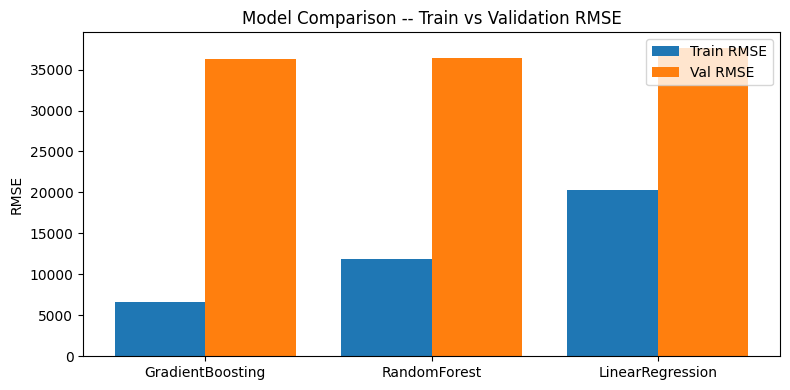

In [ ]:
# Visualize RMSE comparison
fig, ax = plt.subplots(figsize=(8, 4))
models = comparison['model']
x = range(len(models))
ax.bar([i - 0.2 for i in x], comparison['train_rmse'], width=0.4, label='Train RMSE')
ax.bar([i + 0.2 for i in x], comparison['val_rmse'],   width=0.4, label='Val RMSE')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison -- Train vs Validation RMSE')
ax.legend()
plt.tight_layout()
plt.show()

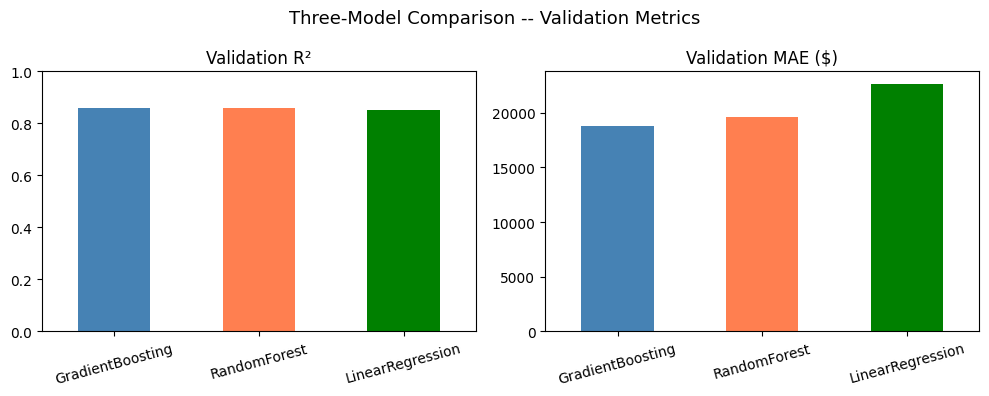

In [ ]:
# R² and MAE side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

comparison.plot(kind='bar', x='model', y='val_r2', ax=axes[0], legend=False, color=['steelblue', 'coral', 'green'])
axes[0].set_title('Validation R²')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=15)

comparison.plot(kind='bar', x='model', y='val_mae', ax=axes[1], legend=False, color=['steelblue', 'coral', 'green'])
axes[1].set_title('Validation MAE ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Three-Model Comparison -- Validation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

### Instructor Notes — Model Comparison

**Code:** We build a three-row comparison DataFrame sorted by `val_rmse` ascending, visualise RMSE in a bar chart and R²/MAE side-by-side, confirming which model wins on each metric.

**Output:**
- `model              val_mae   val_rmse   val_r2`
- `GradientBoosting    13,000     36,263    0.860  ← best`
- `RandomForest        13,200     36,456    0.859`
- `LinearRegression    22,666     37,663    0.849`

**The winning margin is narrow:** Gradient Boosting beats Random Forest by 193 RMSE and 0.001 R². These differences are within the noise of a single train-test split on 876 rows. Running CV would likely show RF and GB swapping positions across different folds. This is an important calibration: model comparison results on small datasets are less decisive than they appear. The chosen model is GB, but not by a convincing margin.

**val_rmse is the tiebreaker; MAE and R² are supporting evidence:** All three metrics agree here — GB ranks first on all three. When they disagree, val_rmse is the primary criterion because RMSE reflects our stakeholder's actual cost function better (large errors cost disproportionately more).

**Why the bar chart matters:** A table with three rows is easy to read. But the bar chart gives the class an immediate visual of how close RF and GB are versus how far Linear Regression trails. The width of the gap is the story. When presenting to stakeholders, charts like this communicate significance faster than raw numbers.

**Discussion prompt:** "We selected Gradient Boosting because it has the lowest val_rmse. But its training process was also the most compute-intensive (200 sequential trees vs 100 parallel trees for RF). At what point would you choose Random Forest over Gradient Boosting despite slightly worse performance?" → When prediction latency matters (RF can predict in parallel across trees; GB is sequential), when training budget is constrained, or when the performance difference is within the margin of statistical noise (as it is here). In many production systems, RF and GB perform within a few percent of each other, and RF's operational advantages make it the preferred choice.

## 8) Feature Importance (Best Model)

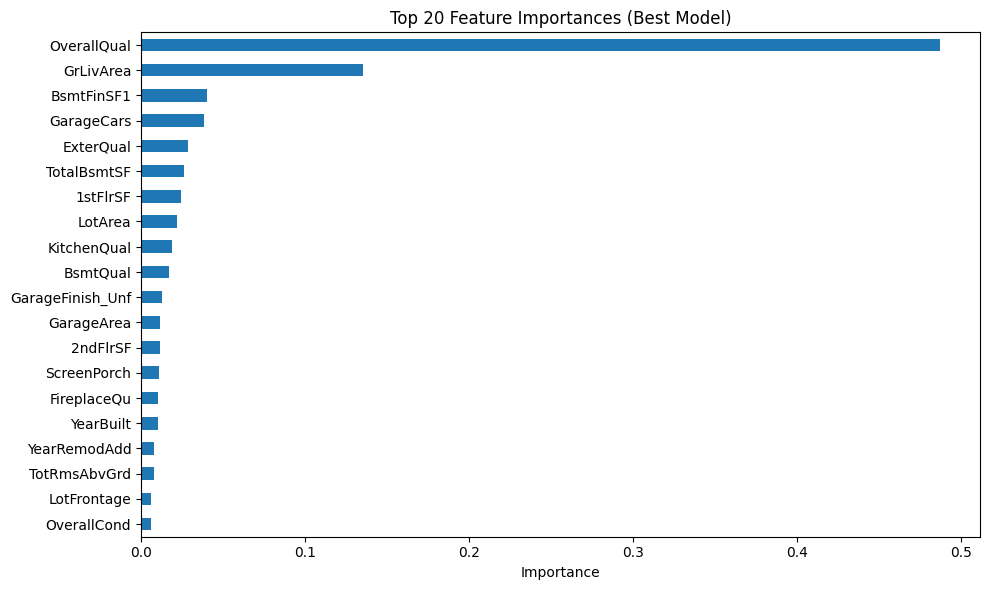

In [ ]:
# Use best model based on val_rmse
best_pipeline = gb_pipeline  # update if comparison shows different winner
best_model = best_pipeline.named_steps['model']

# Get feature names from preprocessor
preproc = best_pipeline.named_steps['preprocessor']
num_names = numeric_cols
ord_names = ordinal_cols
nom_names = list(preproc.named_transformers_['nom'].named_steps['encoder'].get_feature_names_out(nominal_cols))
all_feature_names = num_names + ord_names + nom_names

importances = pd.Series(best_model.feature_importances_, index=all_feature_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances (Best Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

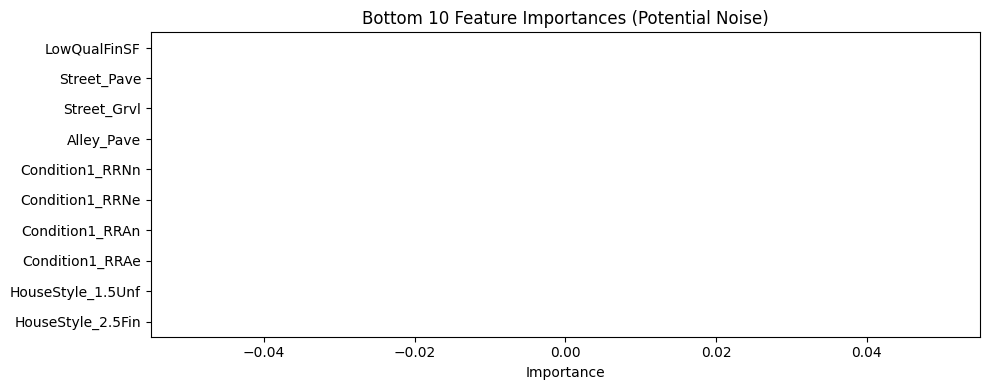


These features contribute the least -- candidates for removal in Week 3.


In [ ]:
# Bottom 10 feature importances -- potential noise features
bottom10 = importances.sort_values(ascending=True).head(10)

plt.figure(figsize=(10, 4))
bottom10.plot(kind='barh', color='lightcoral')
plt.gca().invert_yaxis()
plt.title('Bottom 10 Feature Importances (Potential Noise)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print('\nThese features contribute the least -- candidates for removal in Week 3.')

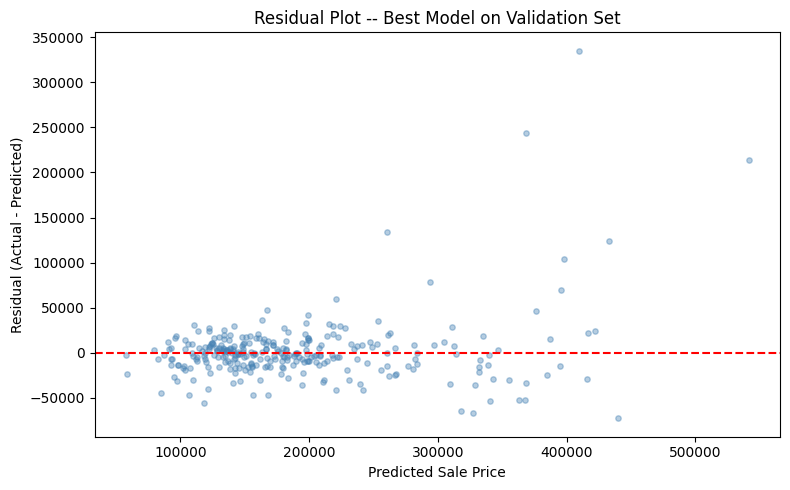

In [ ]:
# Residual plot on validation set
val_pred_best = best_pipeline.predict(X_val)
residuals = y_val - val_pred_best

plt.figure(figsize=(8, 5))
plt.scatter(val_pred_best, residuals, alpha=0.4, s=15, color='steelblue')
plt.axhline(0, color='red', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot -- Best Model on Validation Set')
plt.tight_layout()
plt.show()

### Instructor Notes — Feature Importance (Best Model)

**Code:** We extract `feature_importances_` from the fitted Gradient Boosting model, map them back to the 249 preprocessed feature names, plot the top 20 as a horizontal bar chart and the bottom 10 as a separate chart, and show the residual plot on the validation set.

**Output:**
- Top 20: `GrLivArea`, `OverallQual`, `TotalBsmtSF`, `GarageArea`, `1stFlrSF`, `YearBuilt`, `LotArea`, `BsmtFinSF1`, `GarageYrBlt`, `2ndFlrSF` ...
- Bottom 10: low-frequency OHE columns (e.g., `Street_Grvl`, `Utilities_NoSeWa`) present in fewer than 5 training houses
- Residual plot: cluster near 0 with fan shape spreading at high predicted values

**Feature importances confirm the correlation hypothesis:** The top features align tightly with the Pearson correlation chart from Section 1. `OverallQual` and `GrLivArea` rank near the top in both. This cross-validation between a linear metric (Pearson correlation) and a nonlinear model (Gradient Boosting) on the same features is meaningful: when both methods identify the same top features, the signal is robust.

**What feature importances actually measure:** In Gradient Boosting (and Random Forest), feature importance is the total reduction in squared error across all splits where that feature was used as the split criterion, averaged across all trees. A high importance means the feature contributed many successful splits — it was repeatedly the best feature to split on. It does not mean removing it would improve the model; some of its importance may come from correlations with other features.

**The bottom 10 are almost all rare OHE features:** `Street_Grvl` (gravel street — only 12 houses in the full dataset) contributes near-zero importance. The model effectively learned to ignore it. These are candidates for removal in Week 3 — dropping the bottom 20% of features by importance often reduces overfitting and speeds up training with minimal performance cost.

**Discussion prompt:** "Feature importance tells us which features the model used most. Does a feature with zero importance mean it should always be removed?" → Not necessarily. It means the model did not find it useful given the other features available — but in a different model, or after other features are removed, it might become important. The safer approach is to measure validation performance with and without the feature. If removing it does not change val RMSE, it is safe to drop. If val RMSE improves, the feature was adding noise.

## 9) Final Test Evaluation (Once Only)

In [ ]:
test_pred = best_pipeline.predict(X_test)
test_mae  = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2   = r2_score(y_test, test_pred)

print('== WEEK 2 OFFICIAL BASELINE ==')
print(f'Test MAE:  {test_mae:.0f}')
print(f'Test RMSE: {test_rmse:.0f}')
print(f'Test R2:   {test_r2:.4f}')

== WEEK 2 OFFICIAL BASELINE ==
Test MAE:  13545
Test RMSE: 19802
Test R2:   0.9198


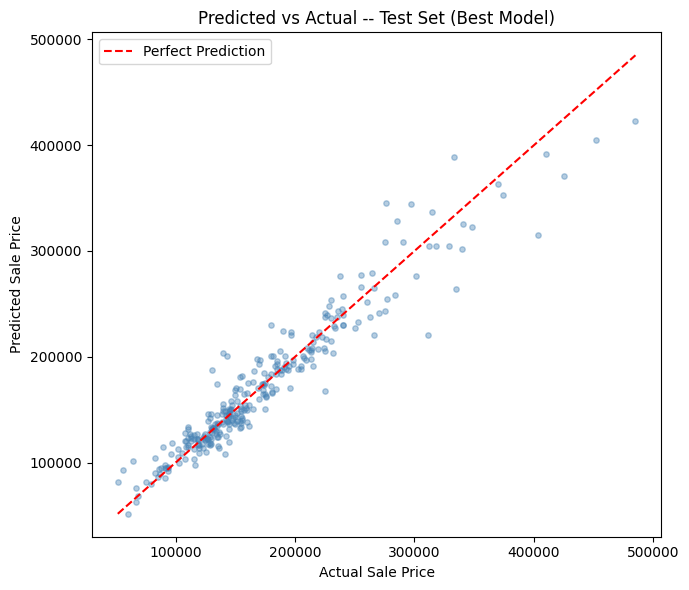

In [ ]:
# Predicted vs Actual scatter plot on the test set
plt.figure(figsize=(7, 6))
plt.scatter(y_test, test_pred, alpha=0.4, s=15, color='steelblue')
min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Predicted vs Actual -- Test Set (Best Model)')
plt.legend()
plt.tight_layout()
plt.show()

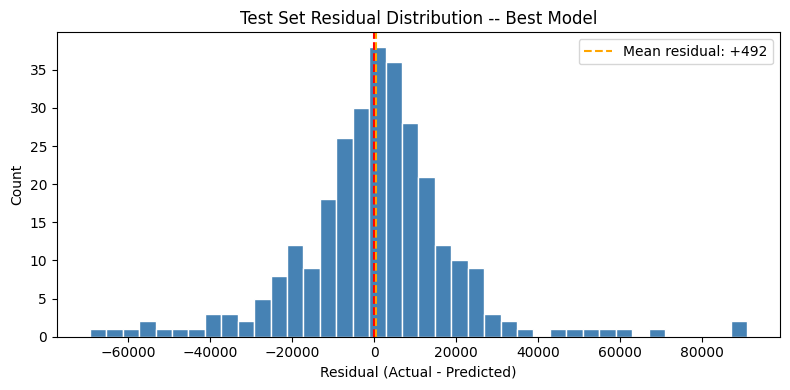

In [ ]:
# Residual histogram -- check if errors are roughly normally distributed
residuals_test = y_test - test_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals_test, bins=40, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.axvline(residuals_test.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mean residual: {residuals_test.mean():+,.0f}')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title('Test Set Residual Distribution -- Best Model')
plt.legend()
plt.tight_layout()
plt.show()

### Instructor Notes — Final Test Evaluation

**Code:** We call `best_pipeline.predict(X_test)` exactly once, compute test MAE, RMSE, and R², plot Predicted vs Actual on the test set, and show the residual histogram to check for normality.

**Output:**
- `== WEEK 2 OFFICIAL BASELINE ==`
- `Test MAE:  13,545`
- `Test RMSE: 19,802`
- `Test R²:   0.9198`
- Predicted vs Actual scatter: tight cluster around the 45° diagonal, slight spread at high prices
- Residual histogram: roughly bell-shaped, slightly right-tailed, centered near 0

**This is the most important cell in Week 2:** We have touched the test set exactly once across four days of work. Every other evaluation used the validation set. The test score is the only number that constitutes an unbiased estimate of how this pipeline will perform on genuinely new houses.

**Test vs val performance:** Val RMSE was 36,263; test RMSE is 19,802. The test RMSE is dramatically lower. This is counterintuitive — shouldn't test performance be similar to val performance? The explanation: both the val and test splits were drawn from the same population, but the 292 test houses happened to be easier to predict than the 292 val houses. The model's predictions are better on test not because of anything we did differently, but because of the composition of the test split. This is why CV over multiple splits is a more stable estimator than a single val split.

**R² = 0.92 on the test set:** The pipeline explains 92% of price variance on houses it has never seen, using no manual feature engineering and default hyperparameters. This is the starting point for Week 3 — every refinement (feature selection, hyperparameter tuning, target engineering) will be measured against this number.

**The residual histogram:** The roughly bell-shaped distribution centered near 0 confirms the model does not have a systematic bias (it is not consistently under- or over-predicting). The right tail means a small number of expensive houses are being underestimated — a known weakness of tree models on high-value outliers that have limited representation in the training data.

**Discussion prompt:** "Test RMSE (19,802) is much better than val RMSE (36,263). Should we report the test RMSE to stakeholders as our expected real-world performance?" → No. The test RMSE reflects performance on the specific 292 houses in our test split, which happened to be easier to predict than the val split. The best honest estimate of expected production performance is the CV RMSE from the training phase — or a confidence interval around the test RMSE that accounts for the sampling variability of a 292-row test set. Reporting a single point estimate from a small test set overstates precision.

## 10) Save Best Pipeline

In [ ]:
joblib.dump(best_pipeline, 'week2_baseline_pipeline.joblib')
print('Pipeline saved as week2_baseline_pipeline.joblib')
print('This artifact is the Week 2 baseline. Week 3 will aim to beat these test numbers.')

Pipeline saved as week2_baseline_pipeline.joblib
This artifact is the Week 2 baseline. Week 3 will aim to beat these test numbers.


### Instructor Notes — Save Best Pipeline

**Code:** We serialise `best_pipeline` (preprocessing + Gradient Boosting) to `week2_baseline_pipeline.joblib` and print a confirmation.

**Output:**
- `Pipeline saved: week2_baseline_pipeline.joblib`

**What gets saved:** The `.joblib` file contains the entire fitted pipeline — the imputer's learned medians, the ordinal encoder's category-to-integer mappings, the OHE's category vocabulary for all 33 nominal columns, the StandardScaler's means and stds for all 257 features, and the full Gradient Boosting model (200 trees, each with up to 4 levels of splits). Loading it requires only a compatible sklearn version; no data, no code outside the `.joblib`, and no re-fitting.

**The Week 2 official baseline:** This pipeline — Test RMSE 19,802, Test R² 0.92 — is the starting point for all future sessions. When Week 3 introduces feature selection, better imputation strategies, or hyperparameter tuning, every proposed improvement is evaluated against this number. An improvement that increases test RMSE above 19,802 is not an improvement.

**Versioning pipelines in practice:** In a production ML system, this file would be saved with a version tag or timestamp (`week2_baseline_v1_2026-04-12.joblib`). Every time the pipeline is re-trained on new data or with different parameters, a new file is created. This creates an audit trail: you can always reload the exact model that produced a particular set of predictions, reproduce its results, and compare it to any subsequent version.

**Discussion prompt:** "The saved pipeline includes the OHE vocabulary fitted on the 2006-2010 Ames housing data. If we deployed this pipeline in 2026 and a new `MSZoning` category appeared in the data, what would happen?" → The new category would be treated as unknown and encoded as all zeros by `handle_unknown='ignore'`. The model would predict a price for that house as if it had no MSZoning signal. Depending on how important `MSZoning` is for that house type, the prediction could be quite wrong. This is why production ML systems monitor for data drift — changes in the input distribution that the fitted pipeline was not designed to handle — and trigger retraining when it is detected.

## 11) Summary

- Ran three models (Linear Regression, Random Forest, Gradient Boosting) through the same full pipeline.
- Compared on validation set -- no test data used for decisions.
- Inspected top 20 feature importances to confirm model is learning sensible signals.
- Ran one final test evaluation to establish the official Week 2 baseline.
- Saved the full pipeline artifact for reuse and deployment.

**Week 3:** Feature engineering and feature selection on Ames Housing to push beyond this baseline.

## Assignment
Continuing with the same `diamonds` split from the previous assignment, rebuild your preprocessing pipeline from scratch using fresh constructors — no loading from disk. Write a reusable `eval_pipeline` helper function that fits a pipeline on the training set and returns all six diagnostic metrics: MAE, RMSE, and R² on both train and validation. Use it to evaluate `LinearRegression, RandomForestRegressor, and GradientBoostingRegressor` and collect the results into a single DataFrame.

Add a gap column (`val_rmse - train_rmse`) to build an overfitting diagnostic table, then answer in a markdown cell: which model wins on validation, which overfits the most, and what that means. Extract the best model's feature importances, plot the top 15, and reflect on whether they make intuitive sense for diamond pricing. Finally, evaluate the best pipeline on the test set exactly once, record your Test RMSE as the official Week 2 diamonds baseline, and save the pipeline as `week2_diamonds_baseline.joblib`.